# MultiModalQA Dataset Loader Example

This notebook demonstrates how to load and visualize examples from the [MultiModalQA dataset](https://github.com/allenai/multimodalqa). MultiModalQA requires joint reasoning over text, tables, and images.

In [1]:
import os
import sys
import json
import random
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from synib.mydatasets import MultimodalQA_Dataset

src_path = os.path.abspath("../../src")
if src_path not in sys.path:
    sys.path.append(src_path)

# Set paths to the dataset
DATASET_ROOT = "/esat/hagalaz/tpoporda/Projects/SynIB/src/synib/mydatasets/MultimodalQA"
DATASET_DIR = os.path.join(DATASET_ROOT, "dataset")
IMAGES_DIR = os.path.join(DATASET_DIR, "final_dataset_images")

print(f"Dataset Root: {DATASET_ROOT}")

/esat/hagalaz/tpoporda/miniconda3/envs/synib/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/esat/hagalaz/tpoporda/miniconda3/envs/synib/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset Root: /esat/hagalaz/tpoporda/Projects/SynIB/src/synib/mydatasets/MultimodalQA


## 1. Load Data

In [2]:
def load_jsonl(filename):
    path = os.path.join(DATASET_DIR, filename)
    data = []
    with open(path, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    return data

print("Loading questions...")
questions = load_jsonl("MMQA_train.jsonl")

print("Loading context files...")
tables_list = load_jsonl("MMQA_tables.jsonl")
texts_list = load_jsonl("MMQA_texts.jsonl")
images_meta_list = load_jsonl("MMQA_images.jsonl")

# Create lookup dictionaries
tables = {item['id']: item for item in tables_list}
texts = {item['id']: item for item in texts_list}
images_meta = {item['id']: item for item in images_meta_list}

print(f"Loaded {len(questions)} questions.")
print(f"Loaded {len(tables)} tables.")
print(f"Loaded {len(texts)} texts.")
print(f"Loaded {len(images_meta)} image metadata entries.")

Loading questions...
Loading context files...
Loaded 23817 questions.
Loaded 10042 tables.
Loaded 218285 texts.
Loaded 57058 image metadata entries.


### 1.1 Load an example 

QUESTION: who is the movie the revenant based on
ANSWERS: ['Hugh Glass']
SUPPORTING CONTEXT:
  - [TEXT] ID: 6894641dc6fbbd89d50811b0977c0322

--- TABLE CONTEXT ---
 ID: 8a4ffc8c7f0aafbd5418f6b9bd5579d5
Table Title: Filmography | Writer


,Year,Title,Credit,Notes
0,2006,Séance,"Director, written by",
1,2007,Vacancy,Written by,
2,2008,Vacancy 2: The First Cut,Written by,
3,2009,The Hole,Written by,
4,2015,Martyrs,Written by,
5,2015,The Revenant,Screenplay by,Co-wrote with Alejandro Gonzalez Inarritu
6,2017,The Hitman's Bodyguard,Extra special thanks,
7,2018,Overlord,Screenplay by,"Co-wrote screenplay with Billy Ray, based on a..."
8,TBA,"Good Morning, Midnight",Written by,



--- TEXT CONTEXT ---
 [The Resurrected]: Claire Ward hires private investigator John March to look into the increasingly bizarre activities of her husband Charles Dexter Ward, an esteemed Rhode Island chemical engineer. Through a series of conversations with John, Claire reveals Charles's recent unexplained isolation in their carriage house, his sudden uncovering of his family history, and their visitation to an abandoned ancestral farmhouse near Pawtuxet where he found a painting of a man named Joseph Curwen, to whom he bears an uncanny resemblance. Since these events, Charles has purchased and moved into the farmhouse, leaving Claire without explanation.

 [The Revenant (2009 film)]: The film focuses on Second Lieutenant Bart Gregory (David Anders) who has been killed under mysterious circumstances in Iraq. After his friends and girlfriend Janet (Louise Griffiths) attend his funeral, Bart awakens in his grave. Enlisting the help of his best friend, Joey Leubner (Chris Wylde), Bart b

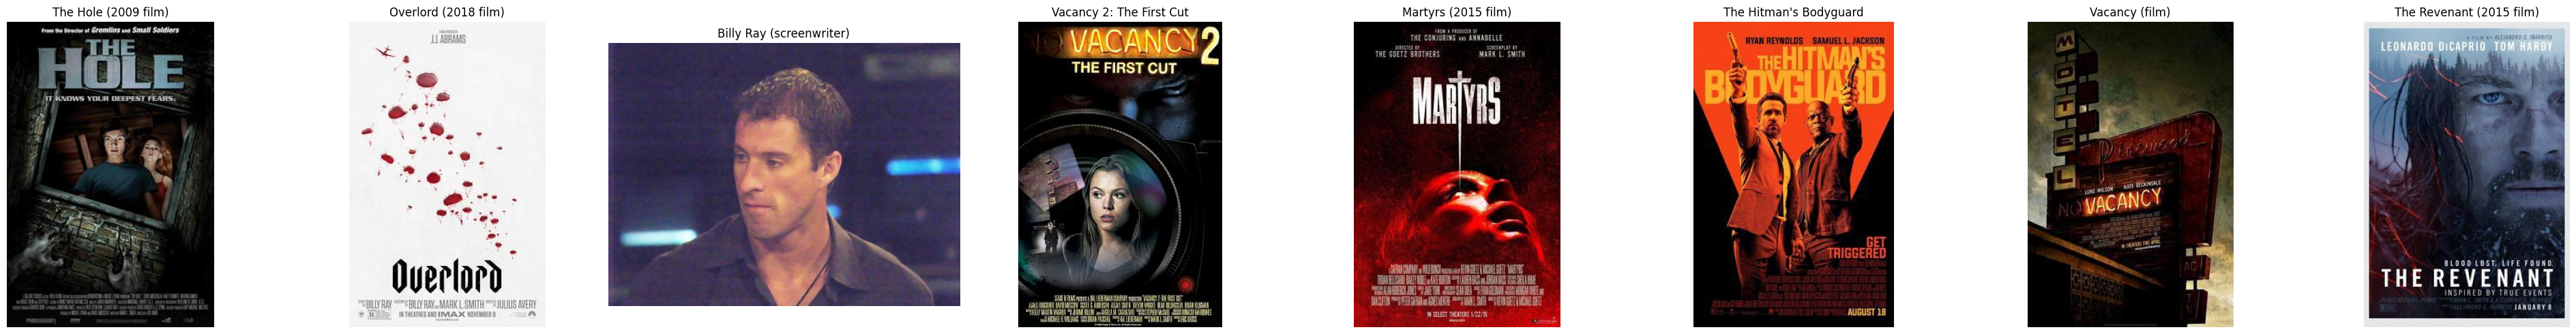

In [3]:
from PIL import Image

def display_table(table_obj):
    # The table data is nested under the 'table' key
    t_data = table_obj.get('table', table_obj)
    
    header = [col['column_name'] for col in t_data.get('header', [])]
    rows = []
    for row in t_data.get('table_rows', []):
        rows.append([cell['text'] for cell in row])
    
    df = pd.DataFrame(rows, columns=header)
    
    title = t_data.get('table_name') or table_obj.get('title') or "N/A"
    print(f"Table Title: {title}")
    display(df)

def display_example(question_idx):
    q = questions[question_idx]
    print("="*80)
    print(f"QUESTION: {q['question']}")
    print(f"ANSWERS: {[a['answer'] for a in q['answers']]}")
    
    supporting = q.get('supporting_context', [])
    if supporting:
        print("SUPPORTING CONTEXT:")
        for ctx in supporting:
            print(f"  - [{ctx['doc_part'].upper()}] ID: {ctx['doc_id']}")
    print("="*80)
    
    metadata = q.get('metadata', {})
    support_ids = {ctx['doc_id'] for ctx in supporting}
    
    # Gather all IDs to display (join candidates and supporting)
    table_ids = set([metadata.get('table_id')] if metadata.get('table_id') else [])
    for ctx in supporting:
        if ctx['doc_part'] == 'table': table_ids.add(ctx['doc_id'])
        
    text_ids = set(metadata.get('text_doc_ids', []))
    for ctx in supporting:
        if ctx['doc_part'] == 'text': text_ids.add(ctx['doc_id'])
        
    image_ids = set(metadata.get('image_doc_ids', []))
    for ctx in supporting:
        if ctx['doc_part'] == 'image': image_ids.add(ctx['doc_id'])
    
    # Table Context
    if table_ids:
        print("\n--- TABLE CONTEXT ---")
        for tid in sorted(list(table_ids)):
            if tid in tables:
                is_support = "[SUPPORTING]" if tid in support_ids else ""
                print(f"{is_support} ID: {tid}")
                display_table(tables[tid])
    
    # Text Context
    if text_ids:
        print("\n--- TEXT CONTEXT ---")
        for tid in sorted(list(text_ids)):
            if tid in texts:
                is_support = "[SUPPORTING]" if tid in support_ids else ""
                print(f"{is_support} [{texts[tid]['title']}]: {texts[tid]['text']}\n")
    
    # Image Context
    if image_ids:
        print("\n--- IMAGE CONTEXT ---")
        valid_images = []
        for img_id in sorted(list(image_ids)):
            if img_id in images_meta:
                img_path = os.path.join(IMAGES_DIR, images_meta[img_id]['path'])
                if os.path.exists(img_path):
                    label = "[SUPPORTING]" if img_id in support_ids else ""
                    valid_images.append((img_id, img_path, label))
        
        if valid_images:
            fig, axes = plt.subplots(1, len(valid_images), figsize=(5 * len(valid_images), 5))
            if len(valid_images) == 1: axes = [axes]
            
            for i, (img_id, img_path, label) in enumerate(valid_images):
                img = Image.open(img_path)
                axes[i].imshow(img)
                title = f"{label} {images_meta[img_id].get('title', img_id)}"
                axes[i].set_title(title.strip())
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else:
            print("No valid images found for the IDs provided.")

random_idx = random.randint(0, len(questions) - 1)
display_example(random_idx)